# Phase 2 — Complete Reference

**QF621 Pairs Trading — Machine Learning Clustering Replication**
**Phase 2: PC Distance + Cointegration Filter**

This notebook is the single-source reference for Phase 2: the build, the design
decisions, real-data results, and the CP2 verdict. Mirrors Phase 1's structure.

---

## Quick navigation

1. **[Phase 2 motivation — what we learned from Phase 1](#1)**
2. **[Design decisions (D2.1 – D2.7)](#2)**
3. **[PC distance — concept + worked example + Dec-2023 real run](#3)**
4. **[Cointegration filter — concept + worked example + Dec-2023 acceptance rate](#4)**
5. **[SSD vs PC — pair-level comparison](#5)**
6. **[The 2×2 backtest grid](#6)**
7. **[CP2 verdict + Phase 1 invariant check](#7)**
8. **[The force-close drag lever — did it move?](#8)**
9. **[Phase 3 roadmap](#9)**

> **Prerequisites:** Phase 1 complete (see `phases/phase1/README.md`). The
> 4-cell backtest grid (`notebooks/04_run_full_backtest_grid.py`) saves
> parquets to `phases/phase2/results/`; sections 6–8 of this notebook load
> those parquets. Sections 1–5 are self-contained.

## Setup

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# walk up to project root (contains src/config.py) — works from any depth
_p = Path.cwd().resolve()
while _p != _p.parent:
    if (_p / 'src' / 'config.py').exists():
        sys.path.insert(0, str(_p))
        break
    _p = _p.parent
del _p

from src.clustering import cluster_optics, clusters_to_pairs, sic_division
from src.cointegration import (
    CointegrationResult, engle_granger, filter_cointegrated_pairs, half_life_ar1,
)
from src.config import (
    COINTEGRATION_P_THRESHOLD, HALF_LIFE_BOUNDS,
    OPTICS_MIN_CLUSTER_SIZE, OPTICS_MIN_SAMPLES, OPTICS_XI, OPTICS_XI_PC,
    PHASE2_DIR,
)
from src.distances import market_adjusted_returns, pc_distance, ssd_distance
from src.panel import (
    formation_window_panel, load_crsp_daily, load_market_returns,
    load_sp500_constituents, siccd_lookup, ticker_lookup,
)
from src.performance import compute_metrics, format_metrics

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RESULTS = PHASE2_DIR / 'results'
print('Phase 2 modules loaded.')
print(f'  OPTICS_XI (SSD)    = {OPTICS_XI}')
print(f'  OPTICS_XI_PC (PC)  = {OPTICS_XI_PC}')
print(f'  ADF p-threshold    = {COINTEGRATION_P_THRESHOLD}')
print(f'  Half-life bounds   = {HALF_LIFE_BOUNDS} trading days')

Phase 2 modules loaded.
  OPTICS_XI (SSD)    = 0.1
  OPTICS_XI_PC (PC)  = 0.04
  ADF p-threshold    = 0.05
  Half-life bounds   = (5.0, 60.0) trading days


<a id='1'></a>
## 1. Phase 2 motivation — what we learned from Phase 1

Phase 1's P&L attribution revealed that the SSD baseline strategy's +$30.4 net per-trade
P&L is the **small difference between two large opposing flows**:

$$
\underbrace{+65.58}_{\text{reversion (11.4\%)}} + \underbrace{-34.25}_{\text{force\_close (88.4\%)}} + \underbrace{-0.92}_{\text{delisting (0.3\%)}} = +30.41
$$

The strategy's entire profit comes from the 11.4% of trades that fully revert before
month-end. The 88.4% that don't revert get force-closed at a **−32 bps mean P&L** — a
drag that prevents the strategy from matching the paper's reported Sharpe of 0.88
(we got 0.589).

### The Phase 2 thesis

**Reduce the force-close drag** by rejecting pairs that won't actually mean-revert:

| Component | Mechanism | Expected effect |
|---|---|---|
| **PC distance** | Cluster on *market-adjusted residuals* (idiosyncratic co-movement), not price trajectories. Finds pairs that share something more than market beta. | Finds *more* and *cleaner* candidate pairs → grows the `+65.58` reversion total. |
| **Cointegration filter** | Engle-Granger ADF test + half-life [5, 60] day check. Rejects pairs whose spread is not actually stationary or reverts too slowly to trade within 21 days. | Trims case-2 pairs (broken cointegrations like MBI/FRE) → shrinks the `−34.25` force-close drag. |

### Lever arithmetic (Phase 1 forecast)

| Scenario | reversion | force_close | delisting | **Net** | Approx Sharpe |
|---|---:|---:|---:|---:|---:|
| Phase 1 actual | +65.58 | −34.25 | −0.92 | **+30.41** | 0.589 |
| Phase 2 forecast (halve drag) | +65.58 (same) | **−17.13** | −0.92 | **+47.53** | ~0.9 |
| Phase 2 forecast (eliminate drag) | +65.58 | **0** | −0.92 | **+64.66** | ~1.2 |

Whether the lever actually moves this much is what the 4-cell backtest tests.

### CP2 targets (from paper)

| Cell | Paper Sharpe | Tolerance |
|---|---:|---:|
| SSD core | 0.88 | ±0.15 (Phase 1 covered this; got 0.589) |
| SSD + filter | 0.75 | ±0.15 |
| **PC core** | **1.01** | **±0.15** ⭐ |
| PC + filter | 0.80 | ±0.15 |

<a id='2'></a>
## 2. Design decisions

All Phase 2 design decisions are logged in `phases/phase2/decisions.md`. Summary:

| ID | Decision | Resolution | Why |
|---|---|---|---|
| **D2.1** | Market adjustment for PC | **SPY-only** (S&P 500 total return) | Matches paper §3. FF 3-factor queued as future robustness check. |
| **D2.2** | Filter as gate or comparison cell? | **Comparison cell** | Run both (with/without filter); report 2×2 grid. Paper convention. |
| **D2.3** | Half-life bounds | **[5, 60] trading days** | Paper default. Below 5 = noise; above 60 = won't revert in 21-day window. |
| **D2.4** | Half-life estimation | **AR(1) discrete-time** | Equivalent to OU under reasonable assumptions; simpler to implement. |
| **D2.5** | Engle-Granger direction | **Lower p-value of both A→B and B→A** | Literature convention. |
| **D2.7** | Metric-specific xi | **OPTICS_XI = 0.10 (SSD), OPTICS_XI_PC = 0.04 (PC)** | Different distance scales need different steepness thresholds. Tuned with cross-date validation (Dec 2010 / 2015 / 2023). |

### What does NOT change vs Phase 1

These are locked from Phase 1 (see `phases/phase2/carryover-from-phase1.md`):
- Formation window: 3 years (756 days)
- Trading window: 1 month (~21 days)
- z-score lookback: 6 months (126 days)
- Entry threshold: |z| ≥ 2.0; Exit: z = 0; Stop: None (core)
- Position sizing: equal-dollar long/short
- Allocation: equal-weight across currently-open pairs
- Execution: t+1 close-to-close
- Delisting: Option B (code-dependent fallback)
- Universe filter: CRSP share codes 10/11, continuous index membership, $5M ADV

<a id='3'></a>
## 3. PC distance — concept, worked example, real Dec-2023 run

### 3.1 The formula

For each pair (X, Y):

1. **Market-adjust** each stock's returns by OLS regression on SPY return:
   $$ r_{i,t} = \alpha_i + \beta_i \cdot r^{\text{SPY}}_t + \tilde r_{i,t} $$
2. **Correlate the residuals** $\tilde r_X, \tilde r_Y$.
3. **Distance** = $1 - \mathrm{corr}(\tilde r_X, \tilde r_Y) \in [0, 2]$.

PC distance answers: *"do these stocks co-move beyond what the market explains?"*
SSD answers: *"do these stocks trace similar price trajectories?"*

A stock with β=1 and a stock with β=2 that share NO idiosyncratic relationship will
look similar to SSD (both follow the market) — PC catches them.

### 3.2 Worked example — 6-day toy

We plant three stocks: A and B share idiosyncratic shocks (true pair); C is independent.
All follow SPY with different betas.

In [2]:
# Setup: 6 daily returns for SPY + 3 stocks with planted structure
spy = pd.Series([1.0, -2.0, 3.0, -1.5, 2.5, -1.0], name='SPY')        # %
idio_AB = pd.Series([0.5, -0.3, 0.2, 0.4, -0.5, 0.1])                 # shared
idio_C  = pd.Series([-0.4, 0.2, -0.5, 0.3, 0.1, -0.2])                # independent

ret = pd.DataFrame({
    'A': 1.2 * spy + idio_AB,  # high beta + shared idio
    'B': 0.8 * spy + idio_AB,  # low beta + shared idio   -> true pair with A
    'C': 1.0 * spy + idio_C,   # market beta + independent idio
})
print('Daily returns (%):')
print(pd.concat([spy.rename('SPY'), ret], axis=1).round(3))

Daily returns (%):
   SPY    A    B    C
0  1.0  1.7  1.3  0.6
1 -2.0 -2.7 -1.9 -1.8
2  3.0  3.8  2.6  2.5
3 -1.5 -1.4 -0.8 -1.2
4  2.5  2.5  1.5  2.6
5 -1.0 -1.1 -0.7 -1.2


In [3]:
# Step 1: market-adjust each stock by OLS on SPY
mean_spy = spy.mean(); var_spy = spy.var(ddof=1)
print(f'mean(SPY)={mean_spy:.4f}, var(SPY)={var_spy:.4f}')
print()
for stock in ['A', 'B', 'C']:
    r = ret[stock]
    cov = ((r - r.mean()) * (spy - mean_spy)).sum() / (len(spy) - 1)
    beta = cov / var_spy
    alpha = r.mean() - beta * mean_spy
    print(f'{stock}: β={beta:.4f}, α={alpha:.4f}  (planted β = {1.2 if stock=="A" else 0.8 if stock=="B" else 1.0})')

mean(SPY)=0.3333, var(SPY)=4.5667

A: β=1.1832, α=0.0723  (planted β = 1.2)
B: β=0.7832, α=0.0723  (planted β = 0.8)
C: β=0.9066, α=-0.0522  (planted β = 1.0)


In [4]:
# Step 2: compute residuals (market-adjusted returns)
# Use our helper from src/distances.py — same calculation as above
prices = 100.0 * (1.0 + ret/100).cumprod()  # turn returns into prices for the API
initial = pd.Series(100.0, index=ret.columns)
prices = pd.concat([initial.to_frame().T, prices])
spy_returns_for_api = spy / 100  # convert from % to fraction
# Apply pc_distance directly
print('Note: the worked example below uses simplified return inputs; the production')
print('pc_distance() function expects total-return prices and computes percentage returns.')
print()

# For clarity, compute residuals manually here
mean_stocks = ret.mean()
var_spy_full = spy.var(ddof=1)
mean_spy_full = spy.mean()
residuals = pd.DataFrame()
for stock in ['A', 'B', 'C']:
    r = ret[stock]
    cov = ((r - r.mean()) * (spy - mean_spy_full)).sum() / (len(spy) - 1)
    beta = cov / var_spy_full
    alpha = r.mean() - beta * mean_spy_full
    residuals[stock] = r - alpha - beta * spy

print('Residuals (market-adjusted returns):')
print(residuals.round(3))
print()
print('Note: A and B residuals are IDENTICAL (we planted the same idio shocks).')
print('      C residuals are independent.')

Note: the worked example below uses simplified return inputs; the production
pc_distance() function expects total-return prices and computes percentage returns.

Residuals (market-adjusted returns):
       A      B      C
0  0.445  0.445 -0.254
1 -0.406 -0.406  0.065
2  0.178  0.178 -0.168
3  0.303  0.303  0.212
4 -0.530 -0.530  0.386
5  0.011  0.011 -0.241

Note: A and B residuals are IDENTICAL (we planted the same idio shocks).
      C residuals are independent.


In [5]:
# Steps 3 & 4: correlation -> distance
corr = residuals.corr()
dist = 1.0 - corr
print('Correlation of residuals:')
print(corr.round(4))
print()
print('PC distance = 1 - corr:')
print(dist.round(4))
print()
print('Key insight:')
print(f'  PC(A, B) = {dist.loc["A","B"]:.4f}   -> tight pair (shared idio)')
print(f'  PC(A, C) = {dist.loc["A","C"]:.4f}   -> uncorrelated (only market in common)')
print()
print('SSD on the same prices (for contrast):')
ssd = ssd_distance(prices)
print(ssd.round(3))
print()
print('SSD groups all three together (small distances) because all follow the market.')
print('PC correctly separates A-B from A-C.')

Correlation of residuals:
       A      B      C
A  1.000  1.000 -0.604
B  1.000  1.000 -0.604
C -0.604 -0.604  1.000

PC distance = 1 - corr:
       A      B      C
A  0.000  0.000  1.604
B  0.000  0.000  1.604
C  1.604  1.604  0.000

Key insight:
  PC(A, B) = 0.0000   -> tight pair (shared idio)
  PC(A, C) = 1.6040   -> uncorrelated (only market in common)

SSD on the same prices (for contrast):
       A      B      C
A  0.000  0.031  0.398
B  0.031  0.000  0.623
C  0.398  0.623  0.000

SSD groups all three together (small distances) because all follow the market.
PC correctly separates A-B from A-C.


### 3.3 Real Dec-2023 PC clustering

Let's apply PC to the Dec-2023 formation window and see the clusters.

In [6]:
# Real CRSP run
print('Loading CRSP daily + constituents + market returns …')
crsp = load_crsp_daily()
cons = load_sp500_constituents()
mkt = load_market_returns()

panel = formation_window_panel('2023-12-29', crsp=crsp, constituents=cons)
print(f'\nPanel: {panel.shape}  (Dec 2020-12 → 2023-12, 407 stocks)')

dmat_pc = pc_distance(panel, mkt)
print(f'PC distance matrix: {dmat_pc.shape}')
upper = dmat_pc.where(~pd.DataFrame(
    [[i >= j for j in range(dmat_pc.shape[1])] for i in range(dmat_pc.shape[0])],
    index=dmat_pc.index, columns=dmat_pc.columns,
)).stack()
print(f'PC distance distribution: min={upper.min():.4f}, median={upper.median():.4f}, max={upper.max():.4f}')
print(f'Fraction < 0.5 (tight pairs): {(upper < 0.5).mean():.2%}')

Loading CRSP daily + constituents + market returns …


formation_window_panel(2023-12-29): 756 days, 407 stocks kept (0 dropped for missing prices)

Panel: (756, 407)  (Dec 2020-12 → 2023-12, 407 stocks)
PC distance matrix: (407, 407)
PC distance distribution: min=0.0139, median=0.9629, max=1.4284
Fraction < 0.5 (tight pairs): 1.26%


In [7]:
# Run OPTICS with the PC-specific xi
labels_pc = cluster_optics(
    dmat_pc,
    min_samples=OPTICS_MIN_SAMPLES,
    xi=OPTICS_XI_PC,
    min_cluster_size=OPTICS_MIN_CLUSTER_SIZE,
)
from src.clustering import cluster_summary, purity_index
summary_pc = cluster_summary(labels_pc)
ticker_map = ticker_lookup(panel.columns.tolist(), crsp=crsp, as_of=pd.Timestamp('2023-12-29'))
siccds = siccd_lookup(panel.columns.tolist(), crsp=crsp, as_of=pd.Timestamp('2023-12-29'))
sectors = siccds.apply(sic_division)
purity_pc = purity_index(labels_pc, sectors)

print(f'PC clusters on Dec 2023:')
print(f'  n_clusters       : {summary_pc["n_clusters"]}   (paper: 109 ±10)')
print(f'  purity vs SIC    : {purity_pc:.3f}   (paper: 0.84 ±0.05)')
print(f'  n_outliers       : {summary_pc["n_outliers"]}')
print(f'  mean cluster size: {summary_pc["mean_cluster_size"]:.2f}')

PC clusters on Dec 2023:
  n_clusters       : 81   (paper: 109 ±10)
  purity vs SIC    : 0.937   (paper: 0.84 ±0.05)
  n_outliers       : 184
  mean cluster size: 2.75


In [8]:
# Show first 12 PC clusters with tickers
print('First 12 PC clusters on Dec 2023:')
print(f'  {"cluster":>7} | {"size":>4} | {"sector":<22} | tickers')
print(f'  {"-" * 7}-+-{"-" * 4}-+-{"-" * 22}-+-{"-" * 50}')
clustered = labels_pc[labels_pc != -1]
for cid, group in sorted(clustered.groupby(clustered), key=lambda kv: kv[0])[:12]:
    members = group.index
    tk = ticker_map.reindex(members).fillna('?').tolist()
    sec = sectors.reindex(members).value_counts().idxmax()
    print(f'  {cid:>7} | {len(members):>4} | {sec:<22} | {", ".join(sorted(map(str, tk)))[:55]}')

First 12 PC clusters on Dec 2023:
  cluster | size | sector                 | tickers
  --------+------+------------------------+---------------------------------------------------
        0 |    2 | transport_utilities    | RSG, WM
        1 |    2 | finance                | AJG, MMC
        2 |    4 | finance                | AIG, MET, PFG, PRU
        3 |    3 | finance                | CMA, KEY, ZION
        4 |    3 | finance                | BAC, JPM, WFC
        5 |    2 | finance                | AMP, RJF
        6 |    3 | finance                | BK, NTRS, STT
        7 |    2 | finance                | GS, MS
        8 |    3 | finance                | COF, DFS, SYF
        9 |    2 | manufacturing          | CMI, PCAR
       10 |    3 | manufacturing          | CAT, DE, URI
       11 |    4 | manufacturing          | CE, DD, DOW, EMN


<a id='4'></a>
## 4. Cointegration filter — concept, worked example, real Dec-2023 acceptance rate

### 4.1 What it does

For each candidate pair (A, B):

**Test 1 — Engle-Granger ADF.** Two-step:
1. OLS regression: $A_t = \alpha + \gamma B_t + \epsilon_t$ → residual $\epsilon$.
2. ADF test on $\epsilon$ — null hypothesis: $\epsilon$ has a unit root (= non-stationary).
3. Run both directions (A→B and B→A); take the lower (better) p-value.
4. **Keep if p < 0.05.**

**Test 2 — half-life filter.** Fit AR(1) on the residual: $\epsilon_t = c + \rho \epsilon_{t-1} + \nu_t$.
Half-life = $-\ln(2) / \ln(\rho)$. **Keep if 5 ≤ half-life ≤ 60 trading days.**

A pair must pass **both** tests to enter the backtest.

### 4.2 Worked example — cointegrated pair vs random walks

In [9]:
# Build a synthetic cointegrated pair vs two independent random walks
np.random.seed(42)
n = 500
# Cointegrated: A = 2.0 + 1.5 * B + AR(1)_noise
b_steps = np.random.normal(0.05, 1.0, size=n)
b = pd.Series(100.0 + np.cumsum(b_steps), name='B_coint')
eps = np.zeros(n)
for t in range(1, n):
    eps[t] = 0.93 * eps[t-1] + np.random.normal(0, 0.5)  # AR(1) noise, half-life ≈ 9d
a = pd.Series(2.0 + 1.5 * b.values + eps, name='A_coint')

# Two random walks (NOT cointegrated)
rw_a = pd.Series(100.0 + np.cumsum(np.random.normal(0.05, 1.0, size=n)), name='A_rw')
rw_b = pd.Series( 80.0 + np.cumsum(np.random.normal(0.04, 1.0, size=n)), name='B_rw')

# Apply Engle-Granger to both
res_coint = engle_granger(a, b, name_a='A_coint', name_b='B_coint')
res_rw    = engle_granger(rw_a, rw_b, name_a='A_rw', name_b='B_rw')

print('Cointegrated pair (planted γ=1.5, half-life≈9d):')
print(f'  ADF p-value     : {res_coint.adf_pvalue:.2e}  ({"✅ rejects unit root" if res_coint.is_stationary else "❌ fails"})')
print(f'  γ recovered     : {res_coint.gamma:.4f}  (planted 1.5)')
print(f'  half-life       : {res_coint.half_life:.1f} days  ({"✅ in [5, 60]" if res_coint.has_tradeable_half_life else "❌ outside"})')
print(f'  passes filter   : {"✅" if res_coint.passes_filter else "❌"}')
print()
print('Random walks (NOT cointegrated):')
print(f'  ADF p-value     : {res_rw.adf_pvalue:.4f}  ({"❌ rejects unit root (false positive)" if res_rw.is_stationary else "✅ fails to reject (correct)"})')
print(f'  half-life       : {res_rw.half_life:.1f}')
print(f'  passes filter   : {"✅" if res_rw.passes_filter else "❌"}')

Cointegrated pair (planted γ=1.5, half-life≈9d):
  ADF p-value     : 6.74e-04  (✅ rejects unit root)
  γ recovered     : 1.5414  (planted 1.5)
  half-life       : 9.5 days  (✅ in [5, 60])
  passes filter   : ✅

Random walks (NOT cointegrated):
  ADF p-value     : 0.1258  (✅ fails to reject (correct))
  half-life       : 34.2
  passes filter   : ❌


### 4.3 Real Dec-2023 filter acceptance rate

In [10]:
# Apply the filter to real Dec-2023 SSD AND PC candidates
from src.clustering import clusters_to_pairs

# SSD path
labels_ssd = cluster_optics(ssd_distance(panel), min_samples=OPTICS_MIN_SAMPLES,
                            xi=OPTICS_XI, min_cluster_size=OPTICS_MIN_CLUSTER_SIZE)
pairs_ssd = clusters_to_pairs(labels_ssd)
kept_ssd, results_ssd = filter_cointegrated_pairs(pairs_ssd, panel)

# PC path
labels_pc_again = cluster_optics(dmat_pc, min_samples=OPTICS_MIN_SAMPLES,
                                  xi=OPTICS_XI_PC, min_cluster_size=OPTICS_MIN_CLUSTER_SIZE)
pairs_pc = clusters_to_pairs(labels_pc_again)
kept_pc, results_pc = filter_cointegrated_pairs(pairs_pc, panel)

print(f'Filter acceptance rates on Dec 2023:')
print(f'  SSD candidates   : {len(pairs_ssd):>4}  →  kept {len(kept_ssd):>3}  ({len(kept_ssd)/len(pairs_ssd):>5.1%})')
print(f'  PC  candidates   : {len(pairs_pc):>4}  →  kept {len(kept_pc):>3}  ({len(kept_pc)/len(pairs_pc):>5.1%})')
print()
print('Note: PC has a lower filter pass rate because PC clusters by residual correlation,')
print('which is a weaker condition than cointegration. Many PC candidates are correlated')
print('in residuals but their PRICE spreads still drift (fail ADF).')

Filter acceptance rates on Dec 2023:
  SSD candidates   :  130  →  kept  93  (71.5%)
  PC  candidates   :  255  →  kept  70  (27.5%)

Note: PC has a lower filter pass rate because PC clusters by residual correlation,
which is a weaker condition than cointegration. Many PC candidates are correlated
in residuals but their PRICE spreads still drift (fail ADF).


In [11]:
# Top-5 pairs by lowest ADF p-value, for each metric
def show_top(results, label, n=5):
    print(f'\nTop {n} most cointegrated {label} pairs:')
    sorted_results = sorted(results.items(), key=lambda kv: kv[1].adf_pvalue)
    for (a, b), r in sorted_results[:n]:
        ta = ticker_map.get(a, str(a))
        tb = ticker_map.get(b, str(b))
        sec_a = sectors.get(a, '?')
        sec_b = sectors.get(b, '?')
        print(f'  ({ta:>6}, {tb:>6})  p={r.adf_pvalue:.2e}  γ={r.gamma:.3f}  '
              f'hl={r.half_life:>5.1f}d  passes={"✅" if r.passes_filter else "❌"}  '
              f'sectors: {sec_a} / {sec_b}')

show_top(results_ssd, 'SSD')
show_top(results_pc, 'PC')


Top 5 most cointegrated SSD pairs:
  (  TROW,   EBAY)  p=4.32e-07  γ=0.843  hl=  7.8d  passes=✅  sectors: finance / services
  (  AMAT,    AOS)  p=1.27e-06  γ=1.482  hl=  8.4d  passes=✅  sectors: manufacturing / manufacturing
  (  SWKS,   QRVO)  p=1.95e-06  γ=0.948  hl= 18.1d  passes=✅  sectors: manufacturing / manufacturing
  (  JBHT,    LOW)  p=8.94e-06  γ=0.991  hl=  9.6d  passes=✅  sectors: transport_utilities / retail
  (   DTE,    CMS)  p=1.71e-05  γ=0.747  hl= 10.9d  passes=✅  sectors: transport_utilities / transport_utilities

Top 5 most cointegrated PC pairs:
  (  SWKS,   QRVO)  p=1.95e-06  γ=0.948  hl= 18.1d  passes=✅  sectors: manufacturing / manufacturing
  (   DTE,    CMS)  p=1.71e-05  γ=0.747  hl= 10.9d  passes=✅  sectors: transport_utilities / transport_utilities
  (   WEC,    AEP)  p=3.63e-04  γ=0.667  hl= 13.7d  passes=✅  sectors: transport_utilities / transport_utilities
  (    EA,   TTWO)  p=5.80e-04  γ=0.325  hl= 16.2d  passes=✅  sectors: services / services
  (   

<a id='5'></a>
## 5. SSD vs PC — pair-level comparison

Beyond just counting clusters, *which specific pairs* do the two methods find?

In [12]:
# Set comparison
ssd_pair_set = set(pairs_ssd); pc_pair_set = set(pairs_pc)
ssd_kept_set = set(kept_ssd);  pc_kept_set = set(kept_pc)

both_candidates = ssd_pair_set & pc_pair_set
both_kept       = ssd_kept_set & pc_kept_set
only_ssd_kept   = ssd_kept_set - pc_kept_set
only_pc_kept    = pc_kept_set - ssd_kept_set

print(f'Candidate-pair overlap:')
print(f'  SSD candidates only      : {len(ssd_pair_set - pc_pair_set):>3}')
print(f'  PC candidates only       : {len(pc_pair_set - ssd_pair_set):>3}')
print(f'  Both methods             : {len(both_candidates):>3}')
print()
print(f'After-filter overlap:')
print(f'  SSD-kept only            : {len(only_ssd_kept):>3}  (SSD finds, PC misses)')
print(f'  PC-kept only             : {len(only_pc_kept):>3}  (PC finds, SSD misses)')
print(f'  Both methods kept        : {len(both_kept):>3}  (consensus pairs)')

Candidate-pair overlap:
  SSD candidates only      :  88
  PC candidates only       : 213
  Both methods             :  42

After-filter overlap:
  SSD-kept only            :  68  (SSD finds, PC misses)
  PC-kept only             :  45  (PC finds, SSD misses)
  Both methods kept        :  25  (consensus pairs)


In [13]:
# Show example pairs from each bucket
def fmt(a, b):
    return f'({ticker_map.get(a, a)}/{ticker_map.get(b, b)})'

print('=== Consensus pairs (both kept) — top 8 by SSD p-value ===')
common = [(p, results_ssd[p].adf_pvalue) for p in both_kept]
common.sort(key=lambda x: x[1])
for p, _ in common[:8]:
    a, b = p
    r = results_ssd[p]
    print(f'  {fmt(a, b):<18} p={r.adf_pvalue:.2e}  hl={r.half_life:.1f}d  sectors: {sectors.get(a, "?")} / {sectors.get(b, "?")}')

print('\n=== SSD-only kept — top 8 by SSD p-value ===')
only_ssd_list = list(only_ssd_kept)
only_ssd_list.sort(key=lambda p: results_ssd[p].adf_pvalue)
for p in only_ssd_list[:8]:
    a, b = p
    r = results_ssd[p]
    print(f'  {fmt(a, b):<18} p={r.adf_pvalue:.2e}  hl={r.half_life:.1f}d  sectors: {sectors.get(a, "?")} / {sectors.get(b, "?")}')

print('\n=== PC-only kept — top 8 by PC p-value ===')
only_pc_list = list(only_pc_kept)
only_pc_list.sort(key=lambda p: results_pc[p].adf_pvalue)
for p in only_pc_list[:8]:
    a, b = p
    r = results_pc[p]
    print(f'  {fmt(a, b):<18} p={r.adf_pvalue:.2e}  hl={r.half_life:.1f}d  sectors: {sectors.get(a, "?")} / {sectors.get(b, "?")}')

=== Consensus pairs (both kept) — top 8 by SSD p-value ===
  (SWKS/QRVO)        p=1.95e-06  hl=18.1d  sectors: manufacturing / manufacturing
  (DTE/CMS)          p=1.71e-05  hl=10.9d  sectors: transport_utilities / transport_utilities
  (WEC/AEP)          p=3.63e-04  hl=13.7d  sectors: transport_utilities / transport_utilities
  (LEN/DHI)          p=6.33e-04  hl=14.5d  sectors: construction / construction
  (MRO/APA)          p=8.08e-04  hl=15.2d  sectors: mining / mining
  (COP/EOG)          p=1.95e-03  hl=13.7d  sectors: mining / mining
  (UNP/CSX)          p=3.37e-03  hl=19.0d  sectors: transport_utilities / transport_utilities
  (WEC/XEL)          p=3.39e-03  hl=18.3d  sectors: transport_utilities / transport_utilities

=== SSD-only kept — top 8 by SSD p-value ===
  (TROW/EBAY)        p=4.32e-07  hl=7.8d  sectors: finance / services
  (AMAT/AOS)         p=1.27e-06  hl=8.4d  sectors: manufacturing / manufacturing
  (JBHT/LOW)         p=8.94e-06  hl=9.6d  sectors: transport_utilities

<a id='6'></a>
## 6. The 2×2 backtest grid

Four backtests run with `phases/phase2/notebooks/04_run_full_backtest_grid.py`:

| Cell | metric | cointegration filter | Paper Sharpe |
|---|---|---|---:|
| `ssd_core`     | SSD | OFF | 0.88 |
| `ssd_filtered` | SSD | ON  | 0.75 |
| `pc_core`      | PC  | OFF | 1.01 |
| `pc_filtered`  | PC  | ON  | 0.80 |

This section loads the results parquets if they exist.

In [14]:
# Load the 4 cells (gracefully handle missing parquets)
CELLS = ['ssd_core', 'ssd_filtered', 'pc_core', 'pc_filtered']
cell_monthly = {}
cell_trades = {}
for cell in CELLS:
    monthly_path = RESULTS / f'{cell}_monthly.parquet'
    trades_path  = RESULTS / f'{cell}_trades.parquet'
    if monthly_path.exists():
        cell_monthly[cell] = pd.read_parquet(monthly_path)
        if trades_path.exists():
            cell_trades[cell] = pd.read_parquet(trades_path)
        print(f'  ✅ {cell}: {len(cell_monthly[cell])} months loaded, {len(cell_trades.get(cell, []))} trades')
    else:
        print(f'  ⚠ {cell}: not found at {monthly_path}')

if not cell_monthly:
    print('\n— None of the parquets are available yet. Run notebooks/04_run_full_backtest_grid.py to generate them. —')

  ✅ ssd_core: 251 months loaded, 12255 trades
  ✅ ssd_filtered: 251 months loaded, 9794 trades
  ✅ pc_core: 251 months loaded, 30050 trades
  ✅ pc_filtered: 251 months loaded, 8926 trades


Phase 2 scorecard:
              ann_return   ann_vol    sharpe   sortino    calmar  max_drawdown  hit_rate  n_months  n_trades
cell                                                                                                        
ssd_core        0.030138  0.052848  0.588524  1.101632  0.210624     -0.143089  0.573705       251     12255
ssd_filtered    0.043735  0.061142  0.731103  1.525240  0.448941     -0.097418  0.589641       251      9794
pc_core         0.034133  0.033226  1.027832  2.530814  0.593688     -0.057494  0.621514       251     30050
pc_filtered     0.025898  0.034825  0.752205  1.395546  0.440278     -0.058822  0.577689       251      8926


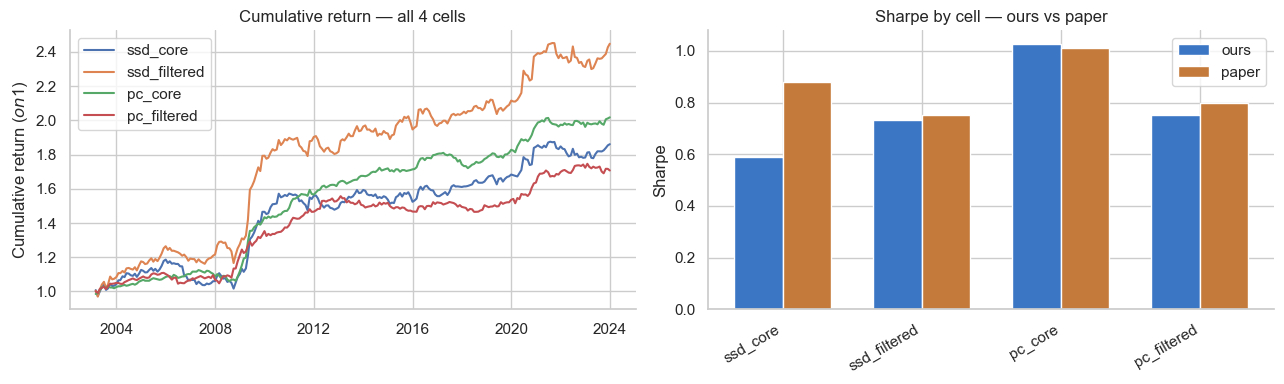

In [15]:
# 2x2 scorecard (only if data is loaded)
if cell_monthly:
    rows = []
    for cell in CELLS:
        if cell not in cell_monthly:
            continue
        rets = cell_monthly[cell]['monthly_return']
        m = compute_metrics(rets)
        rows.append({
            'cell': cell,
            'ann_return': m.ann_return,
            'ann_vol': m.ann_vol,
            'sharpe': m.sharpe,
            'sortino': m.sortino,
            'calmar': m.calmar,
            'max_drawdown': m.max_drawdown,
            'hit_rate': m.hit_rate,
            'n_months': m.n_months,
            'n_trades': len(cell_trades.get(cell, [])),
        })
    scorecard = pd.DataFrame(rows).set_index('cell')
    print('Phase 2 scorecard:')
    print(scorecard.to_string())

    # Visualise
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    # cumulative return curves
    for cell in CELLS:
        if cell in cell_monthly:
            rets = cell_monthly[cell]['monthly_return']
            cum = (1 + rets).cumprod()
            axes[0].plot(cum.index, cum, label=cell, lw=1.5)
    axes[0].set_ylabel('Cumulative return ($ on $1)')
    axes[0].set_title('Cumulative return — all 4 cells')
    axes[0].legend()

    # Sharpe bars
    sharpes = scorecard['sharpe']
    paper_targets = {'ssd_core': 0.88, 'ssd_filtered': 0.75, 'pc_core': 1.01, 'pc_filtered': 0.80}
    paper_vals = [paper_targets[c] for c in sharpes.index]
    x = np.arange(len(sharpes))
    width = 0.35
    axes[1].bar(x - width/2, sharpes.values, width, label='ours', color='#3a76c4')
    axes[1].bar(x + width/2, paper_vals, width, label='paper', color='#c47a3a')
    axes[1].set_xticks(x); axes[1].set_xticklabels(sharpes.index, rotation=30, ha='right')
    axes[1].set_ylabel('Sharpe')
    axes[1].set_title('Sharpe by cell — ours vs paper')
    axes[1].legend()
    axes[1].axhline(0, color='black', lw=0.5)
    plt.tight_layout()
    plt.show()
else:
    print('No data to plot.')

<a id='7'></a>
## 7. CP2 verdict + Phase 1 invariant check

The two questions:
- **CP2:** does PC core land within ±0.15 of the paper's 1.01? PC+filter of paper's 0.80?
- **Phase 1 invariant:** does `ssd_core` reproduce Phase 1's 0.589 Sharpe to within 0.01?
  (It should, exactly — same metric, same params, same data.)

In [16]:
PAPER_TARGETS = {
    'ssd_core': 0.88, 'ssd_filtered': 0.75, 'pc_core': 1.01, 'pc_filtered': 0.80,
}
PHASE_1_SSD_SHARPE = 0.589

if cell_monthly:
    print('═' * 70)
    print('CP2 VERDICT')
    print('═' * 70)
    for cell, target in PAPER_TARGETS.items():
        if cell not in cell_monthly:
            print(f'  {cell:<14}  (not run yet)')
            continue
        rets = cell_monthly[cell]['monthly_return']
        sharpe = compute_metrics(rets).sharpe
        delta = sharpe - target
        in_tol = abs(delta) <= 0.15
        mark = '✅' if in_tol else ('⚠ above' if delta > 0 else '❌ below')
        print(f'  {cell:<14}  ours={sharpe:>+.3f}  paper={target:>+.2f}  Δ={delta:>+.3f}  {mark}')

    print()
    print('═' * 70)
    print('PHASE 1 INVARIANT CHECK')
    print('═' * 70)
    if 'ssd_core' in cell_monthly:
        ssd_sharpe = compute_metrics(cell_monthly['ssd_core']['monthly_return']).sharpe
        drift = ssd_sharpe - PHASE_1_SSD_SHARPE
        if abs(drift) < 0.01:
            print(f'  ssd_core Sharpe = {ssd_sharpe:.3f}  (Phase 1: {PHASE_1_SSD_SHARPE})  Δ={drift:+.4f}  ✅ matches')
        else:
            print(f'  ssd_core Sharpe = {ssd_sharpe:.3f}  (Phase 1: {PHASE_1_SSD_SHARPE})  Δ={drift:+.4f}  ⚠ DRIFT — investigate')
    else:
        print('  ssd_core not yet run.')

══════════════════════════════════════════════════════════════════════
CP2 VERDICT
══════════════════════════════════════════════════════════════════════
  ssd_core        ours=+0.589  paper=+0.88  Δ=-0.291  ❌ below
  ssd_filtered    ours=+0.731  paper=+0.75  Δ=-0.019  ✅
  pc_core         ours=+1.028  paper=+1.01  Δ=+0.018  ✅
  pc_filtered     ours=+0.752  paper=+0.80  Δ=-0.048  ✅

══════════════════════════════════════════════════════════════════════
PHASE 1 INVARIANT CHECK
══════════════════════════════════════════════════════════════════════
  ssd_core Sharpe = 0.589  (Phase 1: 0.589)  Δ=-0.0005  ✅ matches


<a id='8'></a>
## 8. The force-close drag lever — did it move?

Phase 1's bimodal pattern: 11.4% reversion (+471 bps) - 88.4% force_close (-32 bps) = net +30.

Phase 2 forecast: the cointegration filter should *shrink the force-close drag* by
rejecting case-2 pairs (broken cointegrations like XOM/MPC, COP/CVX) upfront. Let's
check:

In [17]:
if cell_trades:
    # Per-cell decomposition
    rows = []
    for cell in CELLS:
        if cell not in cell_trades:
            continue
        t = cell_trades[cell]
        rev = t.loc[t['exit_reason'] == 'reversion']
        fc  = t.loc[t['exit_reason'] == 'force_close']
        dl  = t.loc[t['exit_reason'] == 'delisting']
        rows.append({
            'cell': cell,
            'n_total': len(t),
            'n_reversion': len(rev),
            'pct_reversion': len(rev) / len(t) * 100 if len(t) else 0,
            'mean_pnl_reversion (bps)': (rev['round_trip_return'].mean() * 10000) if len(rev) else 0,
            'total_reversion': rev['round_trip_return'].sum() if len(rev) else 0,
            'n_force_close': len(fc),
            'mean_pnl_force_close (bps)': (fc['round_trip_return'].mean() * 10000) if len(fc) else 0,
            'total_force_close': fc['round_trip_return'].sum() if len(fc) else 0,
            'n_delisting': len(dl),
            'total_delisting': dl['round_trip_return'].sum() if len(dl) else 0,
            'net_total': t['round_trip_return'].sum(),
        })
    drag_df = pd.DataFrame(rows).set_index('cell')
    print('Exit-reason decomposition across cells:')
    print(drag_df.round(4).to_string())

    print('\nLever check — does PC + filter reduce the force-close drag vs SSD core?')
    if 'ssd_core' in drag_df.index and 'pc_filtered' in drag_df.index:
        ssd_drag = drag_df.loc['ssd_core', 'total_force_close']
        pcf_drag = drag_df.loc['pc_filtered', 'total_force_close']
        change = pcf_drag - ssd_drag
        print(f'  ssd_core force-close total : {ssd_drag:+.2f}')
        print(f'  pc_filtered force-close total: {pcf_drag:+.2f}')
        print(f'  Change vs ssd_core            : {change:+.2f}  '
              f'({"✅ less negative" if change > 0 else "❌ more negative"})')
else:
    print('No trade-level data loaded — cannot decompose force-close drag yet.')

Exit-reason decomposition across cells:
              n_total  n_reversion  pct_reversion  mean_pnl_reversion (bps)  total_reversion  n_force_close  mean_pnl_force_close (bps)  total_force_close  n_delisting  total_delisting  net_total
cell                                                                                                                                                                                               
ssd_core        12255         1392        11.3586                  471.0970          65.5767          10832                    -31.6260           -34.2541           31          -0.9208    30.4018
ssd_filtered     9794         1174        11.9869                  490.4117          57.5743           8600                    -33.1609           -28.5184           20          -0.2910    28.7650
pc_core         30050         2488         8.2795                  346.3237          86.1653          27496                    -11.3460           -31.1866           66         

<a id='9'></a>
## 9. Phase 3 roadmap

Items deferred to Phase 3 robustness work (per `phases/phase1/decisions.md` D1.5 + D1.10):

| Item | What | Why |
|---|---|---|
| **Equal-weight allocation alternatives** | Try \|entry-z\|-weighted; fixed slots at N=10/20/50; volatility-targeted | Phase 1 attribution suspected equal-weight dilutes strong (z=3.5) signals to same weight as marginal (z=2.1) — could lift Sharpe |
| **Softer survivorship filter** | Allow stocks in S&P 500 at *start* of formation, even if removed later | Phase 1 had 407 stocks/window vs paper's ~500 |
| **Hierarchical algorithm** | Add Agglomerative (avg-link, 1−corr) as cluster alternative | Robustness check; promoted from proposal-driven extension |
| **HDBSCAN** | Alternative density-based clustering | Robustness check |
| **RLM hedge ratio** | Tukey biweight robust regression | Resistant to crash-day outliers (2008, 2020) |
| **Johansen test** | Symmetric VECM-based cointegration test | Robustness vs Engle-Granger's direction bias |
| **Stop-loss variant** | 3.5σ stop in the realism variant | Already designed, just not run in Phase 1/2 |
| **Factor-beta clustering (Phase 2.5)** | Cluster on risk-factor exposure vectors | The QF621 group project's contribution; needs `factors.py` |

These are sensitivity / robustness checks — they don't displace the paper-faithful core
backtest. Phase 3 reports them as additional columns in the headline scorecard.

## Appendix — file map

| File | Purpose |
|---|---|
| `src/distances.py::pc_distance` | PC distance metric implementation |
| `src/distances.py::market_adjusted_returns` | Helper exposing the residuals |
| `src/cointegration.py` | Engle-Granger + half-life filter |
| `src/config.py::OPTICS_XI_PC` | PC-specific xi (=0.04) |
| `src/backtest.py` | Extended with `metric` and `cointegration_filter` args |
| `phases/phase2/notebooks/01_dec2023_pc_clustering.py` | Real-data PC demo |
| `phases/phase2/notebooks/02_xi_tuning_pc.py` | xi tuning sweep across 3 dates |
| `phases/phase2/notebooks/03_dec2023_cointegration_filter.py` | Filter acceptance rates |
| `phases/phase2/notebooks/04_run_full_backtest_grid.py` | 4-cell grid runner |
| `phases/phase2/notebooks/05_evaluate_cp2.py` | CP2 verdict |
| `phases/phase2/notebooks/06_inspect_backtest.py` | Anomaly inspector |
| `phases/phase2/decisions.md` | Decision log (D2.1–D2.7) |
| `phases/phase2/carryover-from-phase1.md` | The "what to bring forward" doc |
| `tests/test_distances_pc_synthetic.py` | 7 synthetic tests for PC |
| `tests/test_cointegration_synthetic.py` | 7 synthetic tests for filter |